## **Assignment: Object Detection**

Jorge Elías García

En este cuaderno se adjunta el mejor modelo encontrado para la tarea de detección de objetos. La arquitectura con la que hemos obtenido mejores resultados ha sido `YOLO11s` en la librería Ultralytics.

In [ ]:
!pip uninstall -y ultralytics ultralytics-thop numpy scipy scikit-learn opencv-python opencv-python-headless
!pip install -U numpy==2.0.2 scipy scikit-learn opencv-python ultralytics

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: opencv-python 4.12.0.88
Uninstalling opencv-python-4.12.0.88:
  Successfully uninstalled opencv-python-4.12.0.88
Found existing installation: opencv-python-headless 4.12.0.88
Uninstalling opencv-python-headless-4.12.0.88:
  Successfully uninstalled opencv-python-headless-4.12.0.88
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 64.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import numpy as np
import torch, torchvision
from ultralytics import YOLO
import os
import shutil
import json
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
numpy: 2.0.2
torch: 2.8.0+cu126
torchvision: 0.23.0+cu126


In [ ]:
# Ajuste de las rutas
BASE_INPUT_PATH = '/kaggle/input/xview-detection'
TRAIN_IMAGES_DIR = os.path.join(BASE_INPUT_PATH, 'xview_train')
JSON_PATH = os.path.join(BASE_INPUT_PATH, 'xview_det_train.json')
WORK_DIR = '/kaggle/working/datasets/xview'

In [ ]:
# Limpiamos el directorio por si acaso
if os.path.exists(WORK_DIR):
    shutil.rmtree(WORK_DIR)


for folder in ['train', 'val']:
    os.makedirs(f'{WORK_DIR}/images/{folder}', exist_ok=True)
    os.makedirs(f'{WORK_DIR}/labels/{folder}', exist_ok=True)

In [ ]:
cat_name_to_id = {
    'Small car': 0,
    'Bus': 1,
    'Truck': 2,
    'Building': 3
}

In [ ]:
def convert_to_yolo(bbox, img_w, img_h):
    # Creación de bbox: [xmin, ymin, xmax, ymax]
    dw = 1. / img_w
    dh = 1. / img_h
    x = (bbox[0] + bbox[2]) / 2.0
    y = (bbox[1] + bbox[3]) / 2.0
    w = bbox[2] - bbox[0]
    h = bbox[3] - bbox[1]

    return max(0, min(1, x * dw)), max(0, min(1, y * dh)), max(0, min(1, w * dw)), max(0, min(1, h * dh))

In [ ]:
with open(JSON_PATH) as f:
    data = json.load(f)

In [ ]:
filename_to_anns = {}
for ann in data['annotations'].values():
    fname = ann['image_id']
    if fname not in filename_to_anns:
        filename_to_anns[fname] = []
    filename_to_anns[fname].append(ann)

In [ ]:
# Separamos train/val usando las claves de 'images'
all_image_keys = list(data['images'].keys())
train_keys, val_keys = train_test_split(all_image_keys, test_size=0.1, random_state=1, shuffle=True)
print(len(train_keys))
print(len(val_keys))

6845
761


**Oversampling de las clases minoritarias**

A la hora de realizar la carga de las imágenes, añadimos oversampling para las clases `Bus` y `Truck`. Concretamente, realizamos 10 réplicas.

In [ ]:
labels_count = 0
files_processed = 0

# --- Añadimos estos contadores, para corroborar que el oversampling ha sido exitoso---
oversampled_images = 0          # nº de imágenes TRAIN que contienen Bus/Truck
oversampled_replicas = 0        # nº de symlinks de imágenes creados como réplica
oversampled_labels_written = 0  # nº de líneas escritas en labels de réplicas
missing_images = 0              # nº de imágenes que no existen en disco (opcional)

for img_key, img_info in tqdm(data['images'].items()):
    # Obtenemos el nombre real del archivo
    raw_filename = img_info['filename']
    filename = os.path.basename(raw_filename)

    img_w = img_info['width']
    img_h = img_info['height']

    subset = 'train' if img_key in train_keys else 'val'

    # Rutas
    src_img = os.path.join(TRAIN_IMAGES_DIR, filename)
    dst_img = os.path.join(WORK_DIR, 'images', subset, filename)

    if os.path.exists(src_img):
        # --------------------
        # 0) Imagen base (symlink)
        # --------------------
        if not os.path.exists(dst_img):
            os.symlink(src_img, dst_img)

        # --------------------
        # 1) Labels base
        # --------------------
        current_anns = filename_to_anns.get(filename, [])

        txt_filename = os.path.splitext(filename)[0] + '.txt'
        txt_path = os.path.join(WORK_DIR, 'labels', subset, txt_filename)

        yolo_lines = []
        for ann in current_anns:
            cat_name = ann['category_id']

            if cat_name not in cat_name_to_id:
                continue

            cat_id = cat_name_to_id[cat_name]
            bbox = ann['bbox']
            x, y, w, h = convert_to_yolo(bbox, img_w, img_h)

            if w > 0 and h > 0:
                yolo_lines.append(f"{cat_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")

        with open(txt_path, 'w') as f_txt:
            for line in yolo_lines:
                f_txt.write(line + "\n")
                labels_count += 1

        files_processed += 1

        # --------------------
        # 2) Oversampling (solo TRAIN): si hay Bus o Truck => 10 réplicas
        # --------------------
        oversample_classes = {"Bus", "Truck"}

        has_bus_or_truck = any(
            (ann['category_id'] in oversample_classes)
            for ann in current_anns
            if ann['category_id'] in cat_name_to_id
        )

        if subset == "train" and has_bus_or_truck:
            oversampled_images += 1

            # Log solo para las primeras 5, para asegurarnos del correcto funcionamiento.
            if oversampled_images <= 5:
                print(f"[OVERSAMPLE] {filename} contiene Bus/Truck -> creando 20 réplicas")

            base_name, ext = os.path.splitext(filename)

            for k in range(1, 11):  # 10 réplicas
                rep_img_name = f"{base_name}_rep{k:02d}{ext}"
                rep_txt_name = f"{base_name}_rep{k:02d}.txt"

                rep_img_path = os.path.join(WORK_DIR, "images", subset, rep_img_name)
                rep_txt_path = os.path.join(WORK_DIR, "labels", subset, rep_txt_name)

                # Symlink réplica (apunta al mismo src)
                if not os.path.exists(rep_img_path):
                    os.symlink(src_img, rep_img_path)
                    oversampled_replicas += 1

                # Labels réplica (mismo contenido)
                if not os.path.exists(rep_txt_path):
                    with open(rep_txt_path, "w") as f_rep:
                        for line in yolo_lines:
                            f_rep.write(line + "\n")
                            oversampled_labels_written += 1
                            labels_count += 1

                files_processed += 1

    else:
        missing_images += 1


print(f"\n¡Proceso finalizado!")
print(f"Imágenes procesadas (incluye réplicas si se crean): {files_processed}")
print(f"Etiquetas (cajas) escritas (incluye réplicas): {labels_count}")
print(f"Imágenes ausentes en disco: {missing_images}")

print("\n--- Oversampling summary ---")
print(f"Imágenes TRAIN con Bus/Truck detectadas: {oversampled_images}")
print(f"Réplicas creadas (symlinks): {oversampled_replicas}")
print(f"Líneas de labels escritas en réplicas: {oversampled_labels_written}")

if oversampled_images == 0:
    print("⚠️ AVISO: No se detectó ninguna imagen TRAIN con Bus/Truck -> no se creó ninguna réplica.")
    print("   Revisa: (1) nombres exactos en ann['category_id'], (2) oversample_classes, (3) que Bus/Truck estén en cat_name_to_id.")

if labels_count > 0:
    print("✅ Éxito: Se han generado las etiquetas correctamente.")
else:
    print("❌ Error: Siguen sin generarse etiquetas. Revisa los nombres de archivo.")


  0%|          | 0/7606 [00:00<?, ?it/s]

[OVERSAMPLE] 2511_66439541-a371-4b68-93c8-8c62da2cd64e.tif contiene Bus/Truck -> creando 20 réplicas
[OVERSAMPLE] 2511_12385679-1e3e-418c-a68c-42db48a9d8f1.tif contiene Bus/Truck -> creando 20 réplicas
[OVERSAMPLE] 2511_d1b05068-b3d7-4c0c-bca7-b56a17e8cdab.tif contiene Bus/Truck -> creando 20 réplicas
[OVERSAMPLE] 2511_08f4cef0-974f-4bd5-9922-da48be81ce13.tif contiene Bus/Truck -> creando 20 réplicas
[OVERSAMPLE] 2511_1c83c6f1-2d49-450e-b7ef-1fdf63003d0e.tif contiene Bus/Truck -> creando 20 réplicas

¡Proceso finalizado!
Imágenes procesadas (incluye réplicas si se crean): 40326
Etiquetas (cajas) escritas (incluye réplicas): 2989565
Imágenes ausentes en disco: 0

--- Oversampling summary ---
Imágenes TRAIN con Bus/Truck detectadas: 3272
Réplicas creadas (symlinks): 32720
Líneas de labels escritas en réplicas: 2508460
✅ Éxito: Se han generado las etiquetas correctamente.


In [ ]:
# Archivo de configuraciones
yaml_content = f"""
path: {WORK_DIR}
train: images/train
val: images/val

nc: 4
names: ['Small car', 'Bus', 'Truck', 'Building']
"""

In [ ]:
with open('xview_data.yaml', 'w') as f:
    f.write(yaml_content)

#### **Training**
Diseñamos y entrenamos una arquitectura  para la tarea de detección de objetos sobre el dataset “xview_detection”.

**Cargamos el modelo, junto a todas las técnicas de regularización y data augmentation empleadas.** La justificación de esta combinación se encuentra detallada en el informe.

In [ ]:
from ultralytics import YOLO

# Usaremos el modelo 11, la versión S concretamente.
model = YOLO('yolo11s.pt')

results = model.train(
    data='xview_data.yaml',
    epochs=30,
    imgsz=640,
    batch=16,        # Limitado por el uso de memoria. El máximo que se ha conseguido usar es 16.
    patience=10,
    name='xview_yolov11s_transfer',
    project='/kaggle/working/runs/detect',
    optimizer='Adam',
    lr0=1e-3,   # 0.001
    lrf=0.1,    # final = 0.001 * 0.1 = 0.0001

    # Regularización agresiva
    weight_decay=1e-3,
    label_smoothing=0.2,

    # Augmentations fuertes
    mosaic=0.85,
    mixup=0.6,
    copy_paste=0.25,

    # Geométricas (moderadas para no destrozar objetos pequeños)
    translate=0.08,
    scale=0.45,
    fliplr=0.5,

    # Fotométricas
    hsv_h=0.02,
    hsv_s=0.60,
    hsv_v=0.45,

    exist_ok=True,
    verbose=True
)

WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in the future.
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.25, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=xview_data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.02, hsv_s=0.6, hsv_v=0.45, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.6, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=0.85, multi_scale=False, name=xview_yolov11s_transfer, nbs=64, nms=False, opset=None, optimize=False, 

**Gráficas**

Añadimos gráficas para visualizar el proceso del entrenamiento, comparando el comportamiento tanto en entrenamiento como validación. De esta manera, podremos interpretar mejor la evolución del modelo y tomar decisiones con información más sólida a la hora de ajustar el diseño y los hiperparámetros.

--- Curvas de Entrenamiento (Pérdida y Precisión) ---


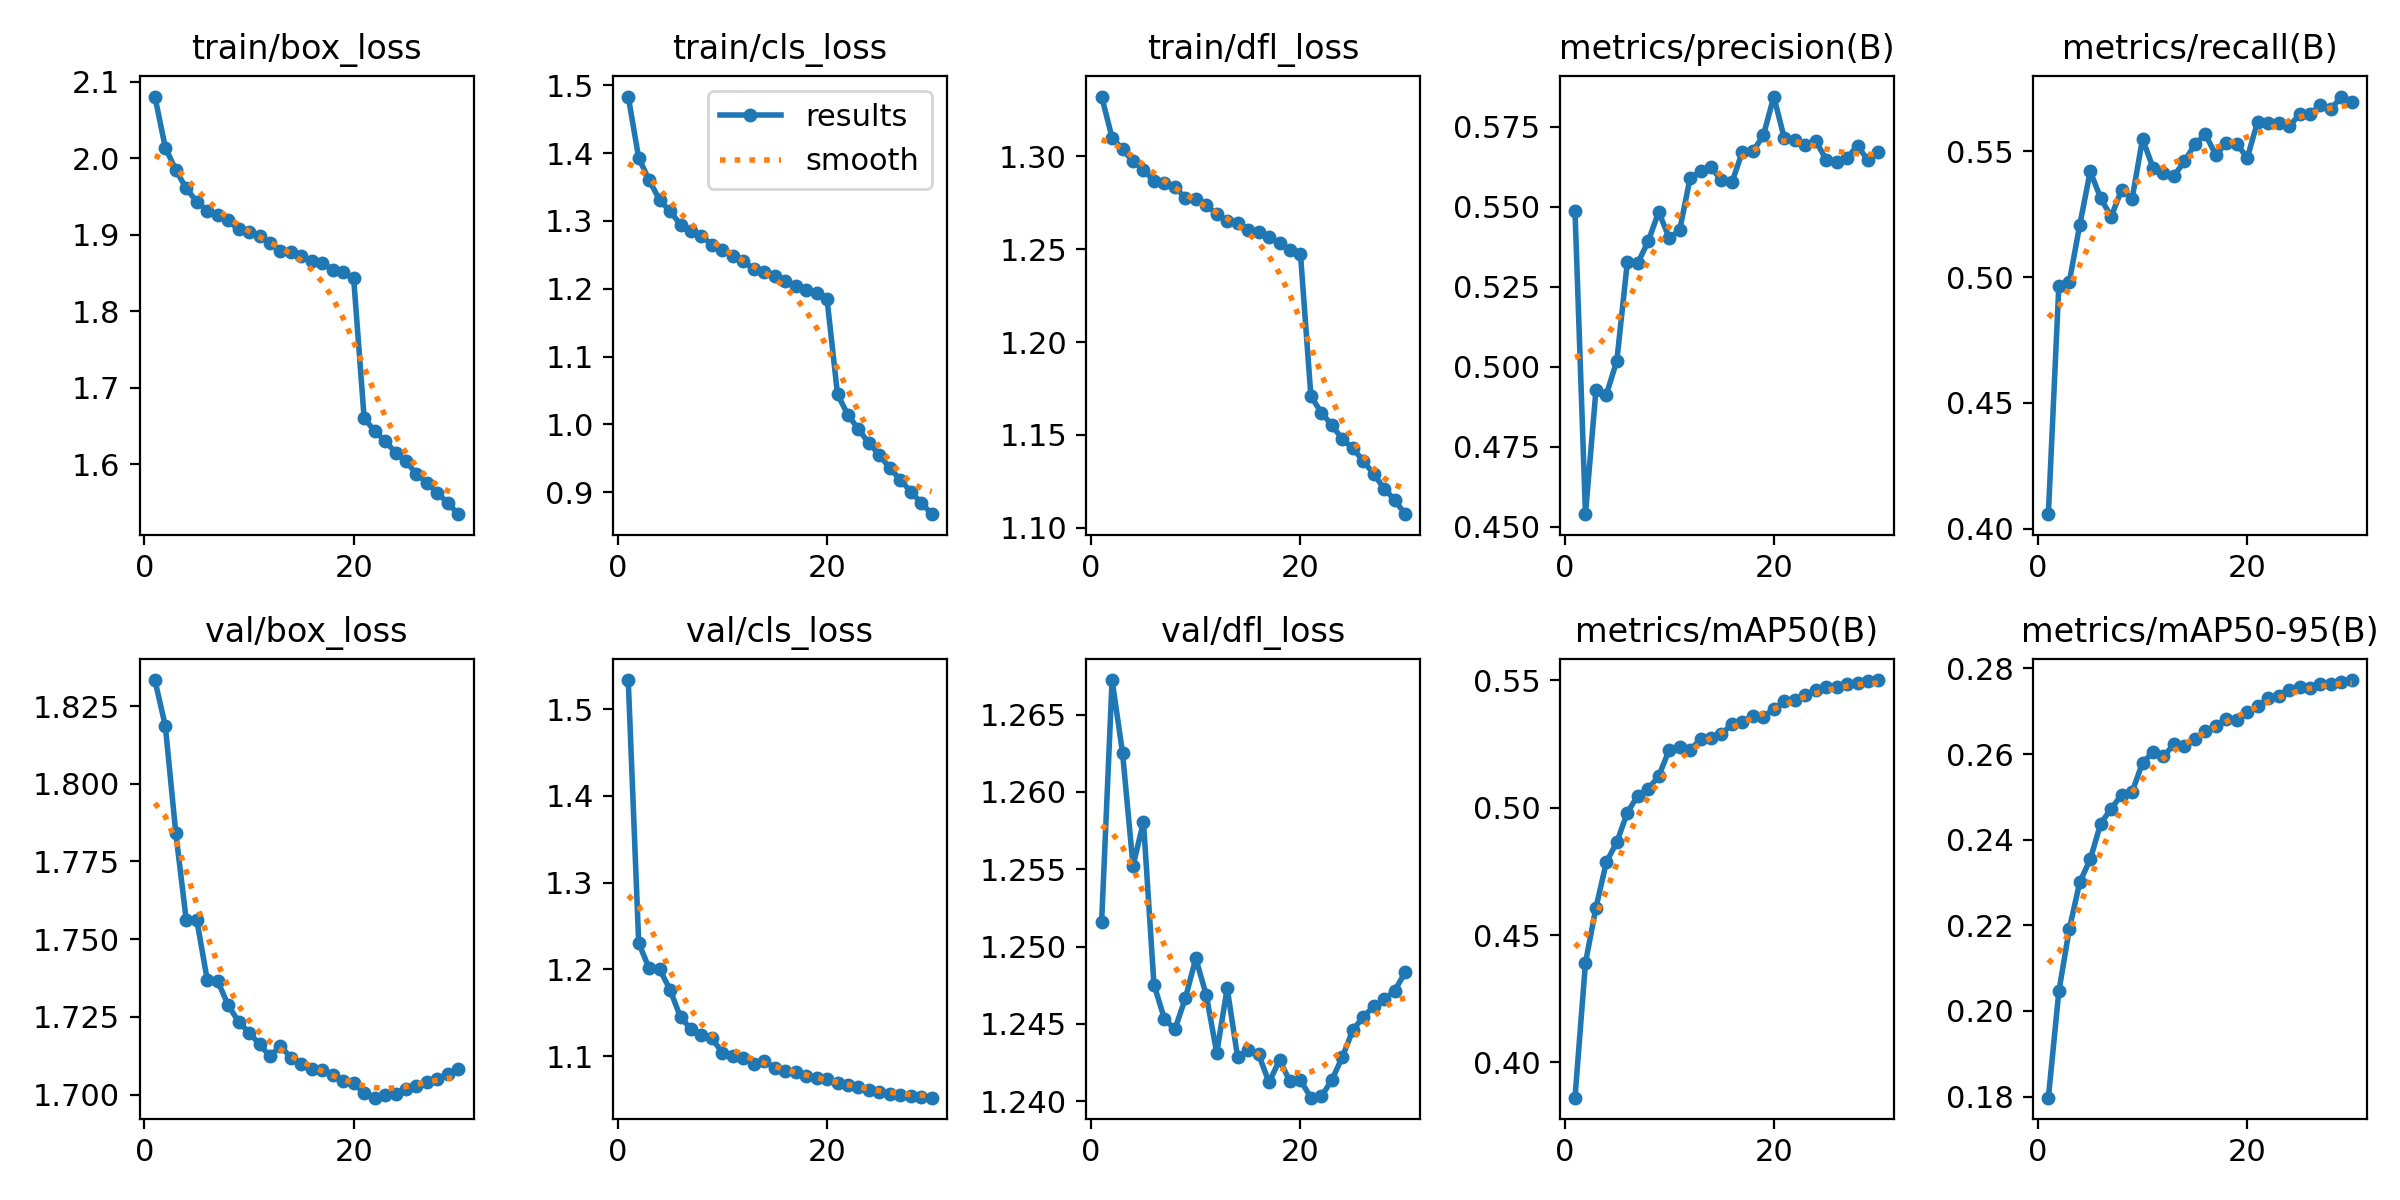


--- Matriz de Confusión ---


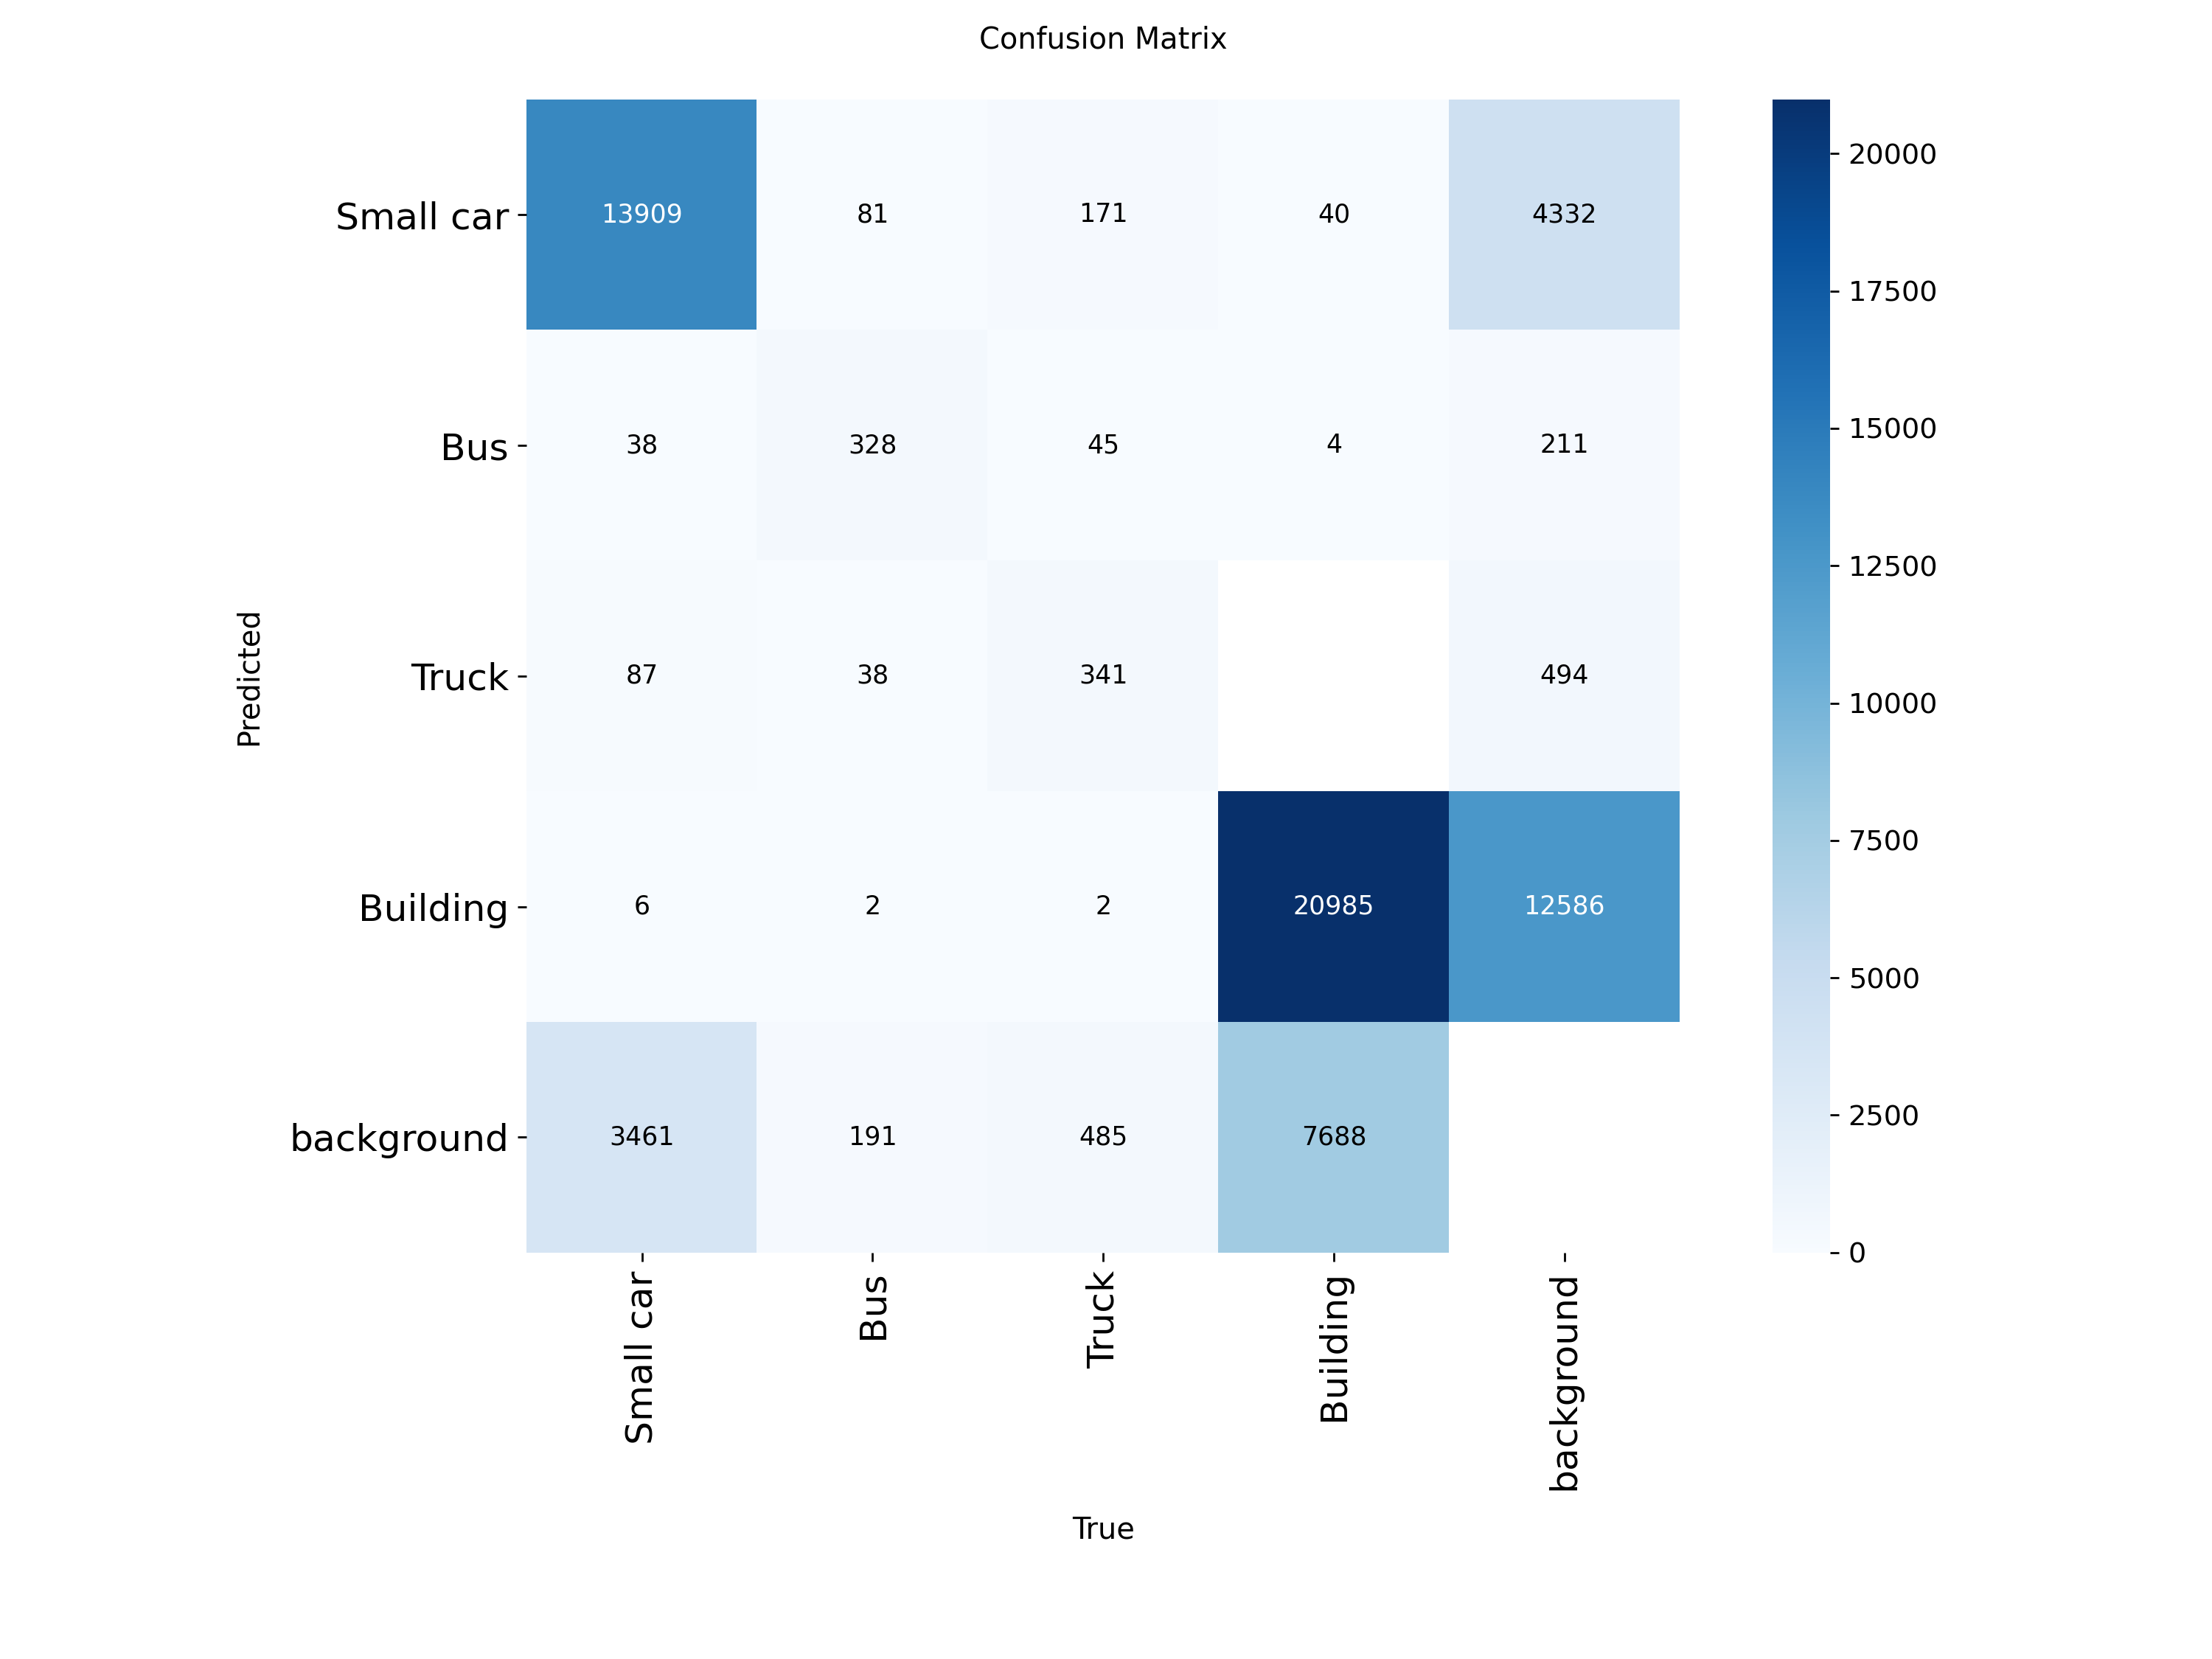


--- Ejemplos de Predicciones en Validación ---


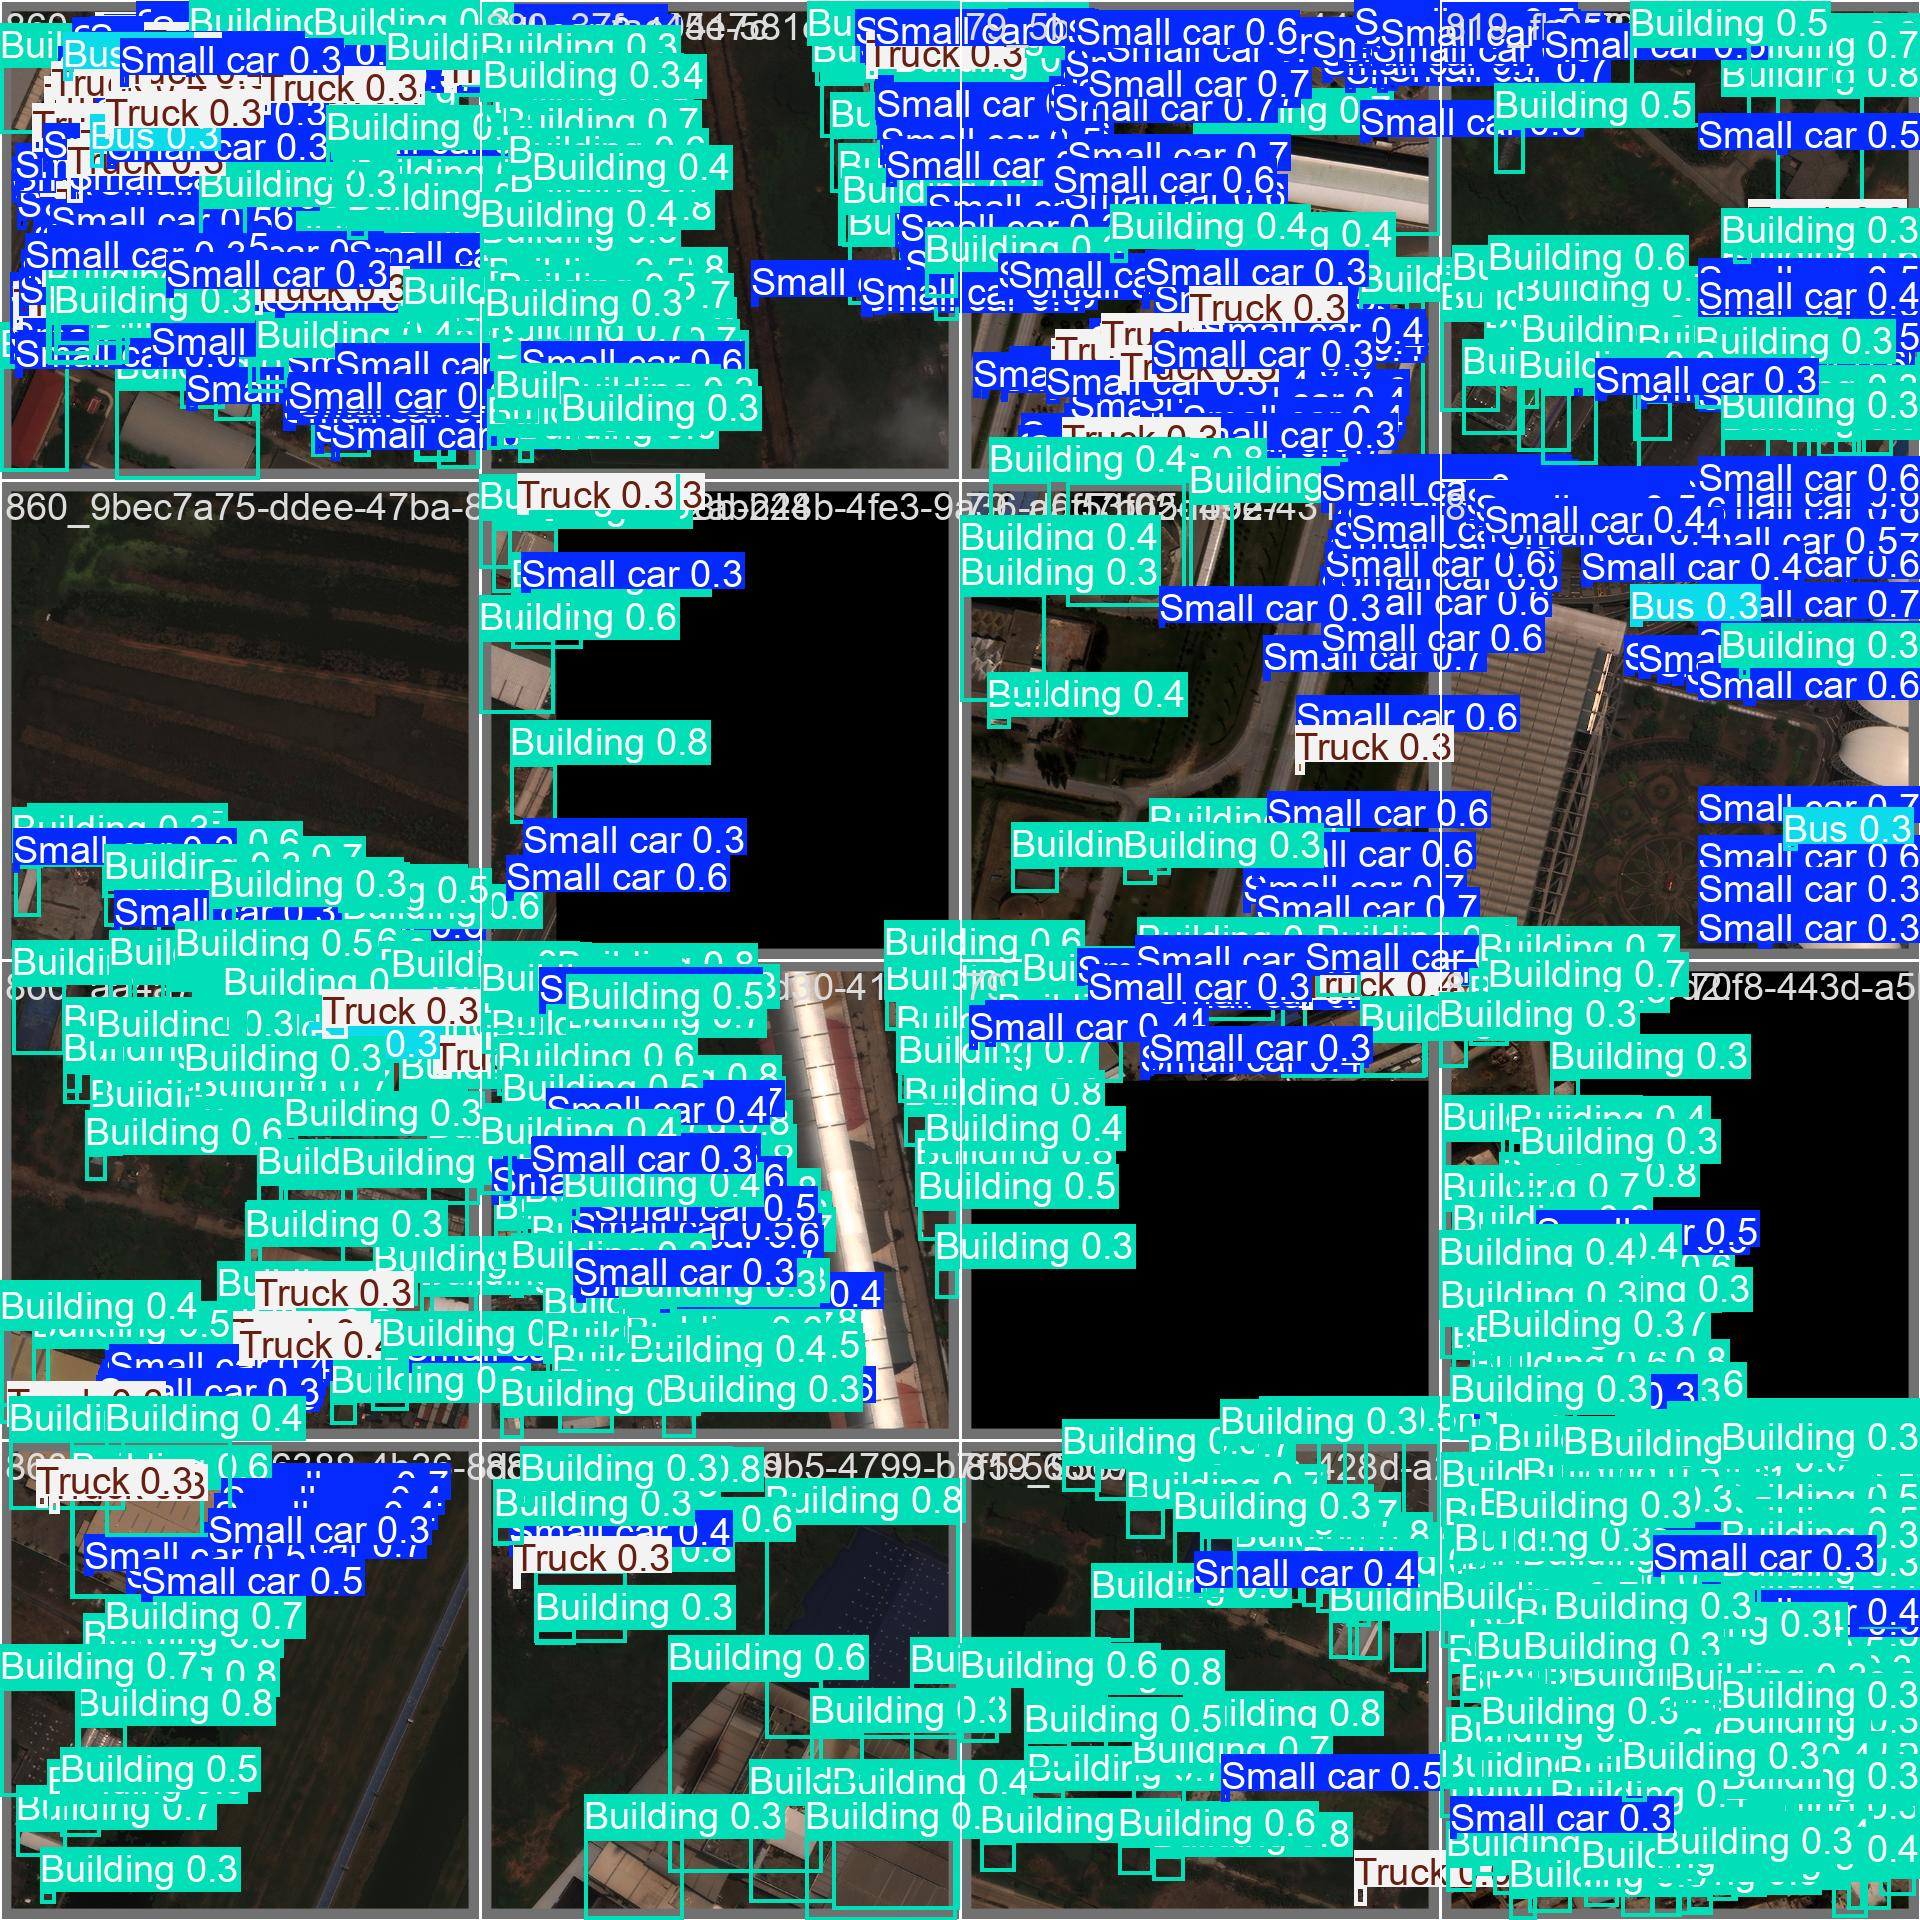

In [ ]:
from IPython.display import Image, display
import os


runs_dir = '/kaggle/working/runs/detect/xview_yolov11s_transfer'
print("--- Curvas de Entrenamiento (Pérdida y Precisión) ---")
display(Image(filename=os.path.join(runs_dir, 'results.png')))

print("\n--- Matriz de Confusión ---")
conf_mat = os.path.join(runs_dir, 'confusion_matrix.png')
if os.path.exists(conf_mat):
    display(Image(filename=conf_mat))
else:
    print("Matriz de confusión no encontrada (quizás no terminó el entrenamiento).")

print("\n--- Ejemplos de Predicciones en Validación ---")
val_pred = os.path.join(runs_dir, 'val_batch0_pred.jpg')
if os.path.exists(val_pred):
    display(Image(filename=val_pred))

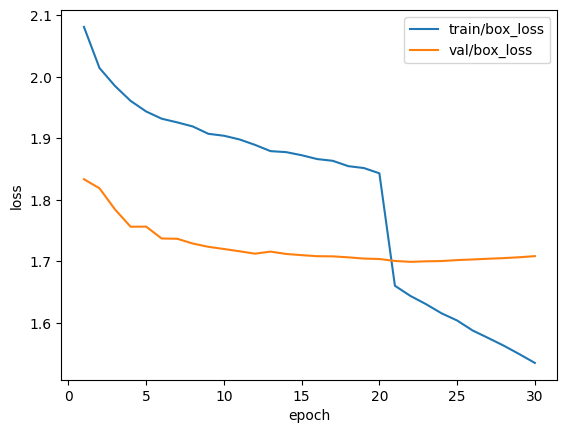

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/kaggle/working/runs/detect/xview_yolov11s_transfer/results.csv"
df = pd.read_csv(csv_path)

plt.figure()
plt.plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
plt.plot(df["epoch"], df["val/box_loss"], label="val/box_loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()


#### **Validation**
Computamos las métricas de validación.

In [ ]:
# Cargar el mejor modelo entrenado
from ultralytics import YOLO
import os

best_model_path = '/kaggle/working/runs/detect/xview_yolov11s_transfer/weights/best.pt'
model = YOLO(best_model_path)
# Evaluamos el modelo
metrics = model.val(data='xview_data.yaml', split='val')

print(f"mAP50-95: {metrics.box.map}")
print(f"mAP50: {metrics.box.map50}")
print(f"Precision: {metrics.box.mp}")    # Precision media
print(f"Recall: {metrics.box.mr}")       # Recall medio

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 100 layers, 9,414,348 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1672.0±466.8 MB/s, size: 1201.3 KB)
val: Scanning /kaggle/working/datasets/xview/labels/val.cache... 761 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 761/761 1.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 48/48 2.5it/s 19.2s
                   all        761      47902      0.568       0.57       0.55      0.277
             Small car        648      17501      0.743      0.769       0.76      0.331
                   Bus        191        640       0.54      0.505      0.514      0.286
                 Truck        243       1044      0.373      0.311      0.268      0.148
              Building        724      28717      0.615      0.694       0.66      0.345
Speed: 1.1ms preprocess, 15.5ms

#### **Testing**

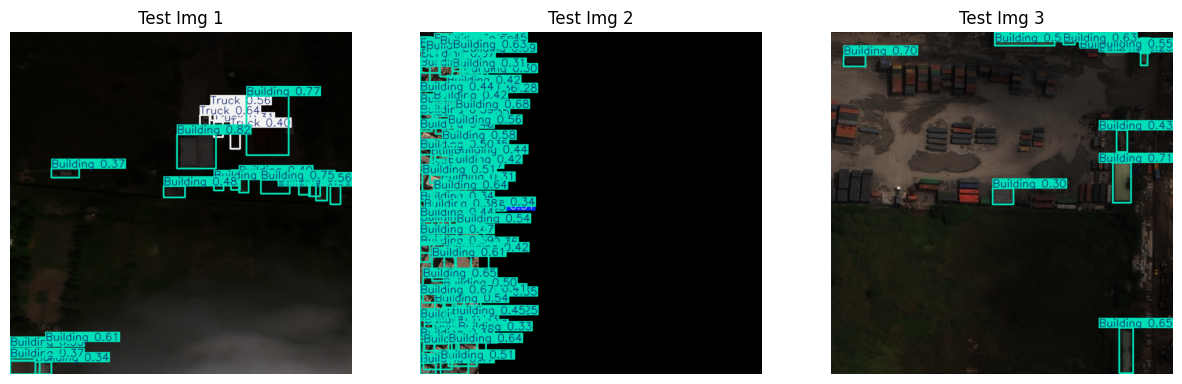

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random

TEST_IMAGES_DIR = '/kaggle/input/xview-detection/xview_test'

# Seleccionamos 3 imágenes para estudiar el comportamiento del modelo
test_files = [os.path.join(TEST_IMAGES_DIR, f) for f in os.listdir(TEST_IMAGES_DIR) if f.endswith('.tif')]
sample_images = random.sample(test_files, 3)

plt.figure(figsize=(15, 15))

for i, img_path in enumerate(sample_images):
    results = model.predict(img_path, conf=0.25, verbose=False)
    res_plot = results[0].plot()
    res_plot = cv2.cvtColor(res_plot, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(res_plot)
    plt.axis('off')
    plt.title(f"Test Img {i+1}")

plt.show()

In [ ]:
results = model.predict(
    source=TEST_IMAGES_DIR,
    conf=0.2,
    imgsz=640,
    stream=True,
    verbose=False
)

# Finalmente, generamos el JSON
predictions_data = {
    "images": {},
    "annotations": {},
    "categories": model.names
}

print("Procesando resultados y guardando...")

imgs_idx = 0
annos_idx = 0

for r in results:
    full_path = r.path
    file_name = os.path.basename(full_path)
    filename_str = f"xview_test/{file_name}"

    boxes = r.boxes.xyxy.cpu().numpy()
    confs = r.boxes.conf.cpu().numpy()
    clss = r.boxes.cls.cpu().numpy()

    num_objects = len(boxes)

    image_data = {
        "image_id": file_name,
        "filename": filename_str,
        "num_objects": num_objects,
        "width": r.orig_shape[1],
        "height": r.orig_shape[0]
    }
    predictions_data["images"][imgs_idx] = image_data
    imgs_idx += 1

    for i in range(num_objects):
        box = boxes[i]
        cls_id = int(clss[i])
        score = float(confs[i])
        category_name = model.names[cls_id]

        annotation_data = {
            "image_id": file_name,
            "category_id": category_name,
            "bbox": [int(box[0]), int(box[1]), int(box[2]), int(box[3])],
            "confidence": str(score)
        }
        predictions_data["annotations"][annos_idx] = annotation_data
        annos_idx += 1

output_file = "prediction.json"
with open(output_file, "w") as f:
    json.dump(predictions_data, f)

print(f"✅ ¡Éxito! Archivo {output_file} generado con {annos_idx} anotaciones de {imgs_idx} imágenes.")

Procesando resultados y guardando...
✅ ¡Éxito! Archivo prediction.json generado con 74389 anotaciones de 852 imágenes.
